In [39]:
# import libraries
import pandas as pd
import numpy as np
import sys

sys.path.append('../')

from src.data_loader import load_cement_data



In [40]:
# load the cement data
df_raw = load_cement_data()
df = df_raw.copy()

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['site_id', 'date']).reset_index(drop=True)

df.head()

,date,site_id,region,behavior,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-01-01,SITE_001,North,aggressive,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448
1,2022-01-02,SITE_001,North,aggressive,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448
2,2022-01-03,SITE_001,North,aggressive,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448
3,2022-01-04,SITE_001,North,aggressive,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448
4,2022-01-05,SITE_001,North,aggressive,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448


In [41]:
# date based features
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)


In [42]:
# England public holidays
holiday_dates = pd.to_datetime([
  # 2022
  '2022-01-03', '2022-04-15', '2022-04-18', '2022-05-02', 
  '2022-06-02', '2022-06-03', '2022-08-29', '2022-09-19',
  '2022-12-26', '2022-12-27',
  # 2023
  '2023-01-02', '2023-04-07', '2023-04-10', '2023-05-01', 
  '2023-05-08', '2023-05-29', '2023-08-28', '2023-12-25', 
  '2023-12-26',
  # 2024
  '2024-01-01', '2024-03-29', '2024-04-01', '2024-05-06', 
  '2024-05-27', '2024-08-26', '2024-12-25', '2024-12-26'
])

df['is_holiday'] = df['date'].isin(holiday_dates).astype(int)


In [43]:
# consumption lag features
lag_days = [1, 3, 7, 14, 28]

for lag in lag_days:
  df[f"lag_{lag}"] = (
df.groupby('site_id')['consumed_tonnes']
    .shift(lag)
  )

In [44]:
# rolling window moving average features
df['rolling_avg_7'] = (
  df.groupby('site_id')['consumed_tonnes']
  .shift(1)
  .rolling(window=7)
  .mean()
  .reset_index(level=0, drop=True)
)

df['rolling_avg_28'] = (
  df.groupby('site_id')['consumed_tonnes']
  .shift(1)
  .rolling(window=28)
  .mean()
  .reset_index(level=0, drop=True)
)

In [45]:
# inventory features - days of coverage
df['avg_daily_consumption'] = df["rolling_avg_28"]

df['days_of_coverage'] = (
  df['closing_inventory_tonnes'] / df['avg_daily_consumption']
)

df['days_of_coverage'] = df['days_of_coverage'].replace(
  [np.inf, -np.inf],
  np.nan
)

In [46]:
# weather features - 3 day rolling rain total, temperature trend
df['rain_3day_total'] = (
  df.groupby('site_id')['rain_mm']
  .shift(1)
  .rolling(window=3)
  .sum()
  .reset_index(level=0, drop=True)
)

df['temp_avg_3day'] = (
  df.groupby('site_id')['avg_temp_c']
  .shift(1)
  .rolling(window=3)
  .mean()
  .reset_index(level=0, drop=True)
)

df['temp_trend_3day'] = df['avg_temp_c'] - df['temp_avg_3day']

In [47]:
df.isnull().sum()

date                          0
site_id                       0
region                        0
behavior                      0
cement_type                   0
planned_pour_tonnes           0
consumed_tonnes               0
opening_inventory_tonnes      0
deliveries_tonnes             0
closing_inventory_tonnes      0
rain_mm                       0
avg_temp_c                    0
silo_capacity                 0
day_of_week                   0
month                         0
quarter                       0
is_weekend                    0
is_holiday                    0
lag_1                        30
lag_3                        90
lag_7                       210
lag_14                      420
lag_28                      840
rolling_avg_7               210
rolling_avg_28              840
avg_daily_consumption       840
days_of_coverage            840
rain_3day_total              90
temp_avg_3day                90
temp_trend_3day              90
dtype: int64

In [48]:
# drop rows with missing values created by lag and rolling features
df = df.dropna().reset_index(drop=True)

In [49]:
# define the features and target variable
features_cols = [
  "planned_pour_tonnes",
  "avg_temp_c",
  "rain_mm",
  "day_of_week",
  "month",
  "quarter",
  "is_weekend",
  "is_holiday",
  "lag_1",
  "lag_3",
  "lag_7",
  "lag_14",
  "lag_28",
  "rolling_avg_7",
  "rolling_avg_28",
  "days_of_coverage",
  "rain_3day_total",
  "temp_avg_3day",
  "temp_trend_3day"
]

target_col = "consumed_tonnes"

x = df[features_cols]
y = df[target_col]

XGB MAPE: 39.52%
XGB RMSE: 10.59
XGBoost Forecast vs Actuals for SITE_001


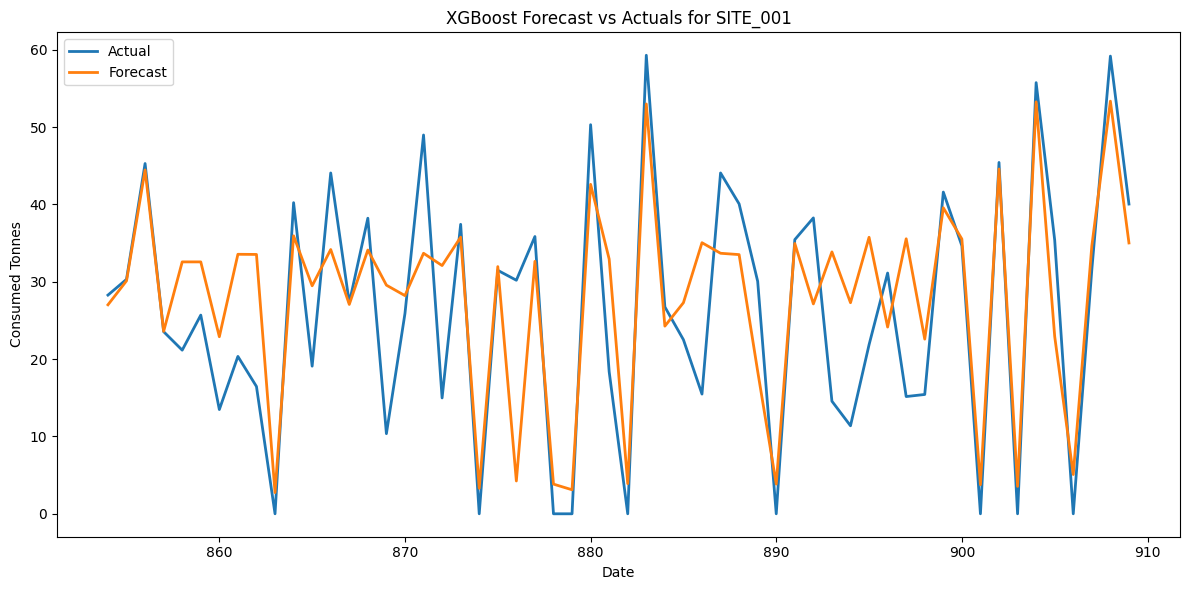

In [50]:
# xgboost model for one site
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot as plt

site_id = 'SITE_001'

site_model_df = df[df['site_id'] == site_id].copy()
site_model_df = site_model_df.sort_values('date')

X = site_model_df[features_cols]
y = site_model_df[target_col]

split_index = int(len(site_model_df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

forecast_horizon = 56

y_test_8w = y_test.iloc[:forecast_horizon]
X_test_8w = X_test.iloc[:forecast_horizon]

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

xgb_model = model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test_8w)

mask = y_test_8w != 0

xgb_mape = np.mean(np.abs((y_test_8w[mask] - y_pred[mask]) / y_test_8w[mask])) * 100
xgb_rmse = np.sqrt(mean_squared_error(y_test_8w[mask], y_pred[mask]))
print(f"XGB MAPE: {xgb_mape:.2f}%")
print(f"XGB RMSE: {xgb_rmse:.2f}")

print("XGBoost Forecast vs Actuals for SITE_001")
plt.figure(figsize=(12, 6))
plt.plot(y_test_8w.index, y_test_8w, label="Actual", linewidth=2)
plt.plot(y_test_8w.index, y_pred, label="Forecast", linewidth=2)
plt.title(f"XGBoost Forecast vs Actuals for {site_id}")
plt.xlabel("Date")
plt.ylabel("Consumed Tonnes")
plt.legend()
plt.tight_layout()
plt.show()


In [51]:
# Wrap up the xgboost model for all sites
xgb_sites_metrics = []
xgb_sites_predictions = []
xgb_feature_importance_df = []

for site_id in df['site_id'].unique():
    try:
        site_df = df[df['site_id'] == site_id].copy()
        site_df = site_df.set_index('date')
        site_df = site_df.sort_values('date')

        y = site_df[target_col]
        x = site_df[features_cols]

        split_index = int(len(site_df) * 0.8)
        y_train, X_train = y.iloc[:split_index], x.iloc[:split_index]
        y_test, X_test = y.iloc[split_index:], x.iloc[split_index:]

        forecast_horizon = 56

        y_test_8w = y_test.iloc[:forecast_horizon]
        X_test_8w = X_test.iloc[:forecast_horizon]

        xgb_model = XGBRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
            n_jobs=-1
        )

        xgb_model.fit(X_train, y_train)

        xgb_forecast = xgb_model.predict(X_test_8w)

        site_predictions = pd.DataFrame({
            'site_id': site_id,
            'date': y_test_8w.index,
            'actual_consumed_tonnes': y_test_8w.values,
            'forecasted_consumed_tonnes': xgb_forecast
        })

        xgb_sites_predictions.append(site_predictions)

        mask = y_test_8w != 0

        mape = np.mean(
            np.abs((y_test_8w[mask] - xgb_forecast[mask]) / y_test_8w[mask])
        ) * 100

        rmse = np.sqrt(
            mean_squared_error(y_test_8w[mask], xgb_forecast[mask])
        )

        xgb_sites_metrics.append({
            'site_id': site_id,
            'MAPE': round(mape, 2),
            'RMSE': round(rmse, 2)
        })

        # feature importance for all sites

        for feature, importance in zip(X_train.columns, xgb_model.feature_importances_):
            xgb_feature_importance_df.append({
                'site_id': site_id,
                'feature': feature,
                'importance': importance
            })

    except Exception as e:
        print(f"Error processing site {site_id}: {e}")

In [52]:
# print the metrics for all sites and overall metrics
xgb_sites_metrics_df = pd.DataFrame(xgb_sites_metrics)
print(xgb_sites_metrics_df)
print("Overall MAPE:", round(xgb_sites_metrics_df['MAPE'].mean(), 2))
print("Overall RMSE:", round(xgb_sites_metrics_df['RMSE'].mean(), 2))


     site_id   MAPE   RMSE
0   SITE_001  39.52  10.59
1   SITE_002   1.23   0.18
2   SITE_003  16.35   6.85
3   SITE_004   4.63   0.93
4   SITE_005  20.10   8.73
5   SITE_006  10.86   5.95
6   SITE_007  21.39   7.41
7   SITE_008  26.85   8.04
8   SITE_009   1.25   0.16
9   SITE_010  34.60   9.40
10  SITE_011  23.74   8.19
11  SITE_012   0.84   0.13
12  SITE_013   4.08   2.99
13  SITE_014   3.92   2.91
14  SITE_015   2.74   0.67
15  SITE_016   8.77   2.81
16  SITE_017  28.60   8.13
17  SITE_018  24.00   8.20
18  SITE_019   1.40   0.29
19  SITE_020  29.23   9.37
20  SITE_021  29.57   9.40
21  SITE_022  32.35   9.57
22  SITE_023   3.82   0.78
23  SITE_024   2.93   1.58
24  SITE_025  28.86  10.08
25  SITE_026   2.74   1.99
26  SITE_027   0.96   0.13
27  SITE_028   2.32   1.14
28  SITE_029   2.80   0.63
29  SITE_030  37.50   9.95
Overall MAPE: 14.93
Overall RMSE: 4.91


In [53]:
# print the predictions for all sites
xgb_sites_predictions_df = pd.concat(
    xgb_sites_predictions, 
    ignore_index=True
)
print(xgb_sites_predictions_df)

       site_id       date  actual_consumed_tonnes  forecasted_consumed_tonnes
0     SITE_001 2024-06-01                   28.28                   27.025133
1     SITE_001 2024-06-02                   30.32                   30.122286
2     SITE_001 2024-06-03                   45.29                   44.462242
3     SITE_001 2024-06-04                   23.55                   23.588629
4     SITE_001 2024-06-05                   21.16                   32.571472
...        ...        ...                     ...                         ...
1675  SITE_030 2024-07-22                   39.86                   31.546555
1676  SITE_030 2024-07-23                    0.00                    3.289762
1677  SITE_030 2024-07-24                   37.38                   37.989937
1678  SITE_030 2024-07-25                   28.68                   32.240776
1679  SITE_030 2024-07-26                   33.33                   25.481941

[1680 rows x 4 columns]


In [54]:
# feature importance for XGBoost model for SITE_001
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance_df

,feature,importance
2,rain_mm,0.288401
0,planned_pour_tonnes,0.199962
15,days_of_coverage,0.145552
1,avg_temp_c,0.046764
11,lag_14,0.046418
16,rain_3day_total,0.038183
14,rolling_avg_28,0.035812
17,temp_avg_3day,0.035177
12,lag_28,0.034259
8,lag_1,0.031031


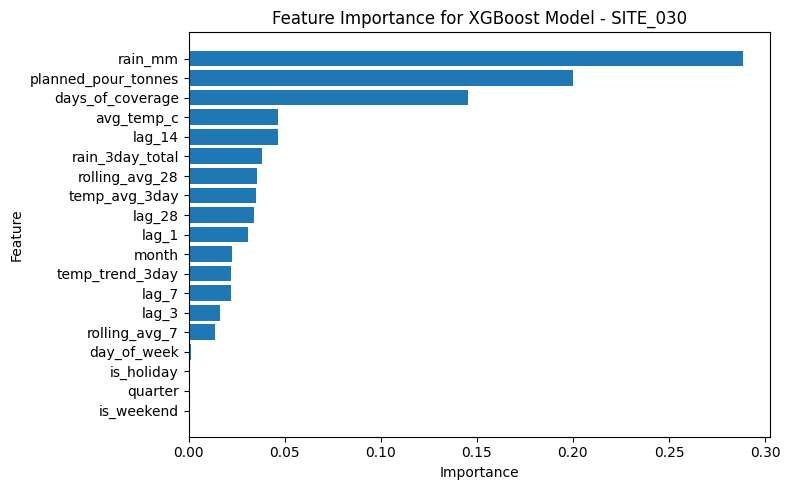

In [55]:
# plot feature importance for XGBoost model for SITE_001
plt.figure(figsize=(8, 5))

plt.barh(
  feature_importance_df['feature'],
  feature_importance_df['importance']
)
plt.gca().invert_yaxis()  
plt.title(f"Feature Importance for XGBoost Model - {site_id}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [56]:
# feature importance for XGBoost model for all sites
xgb_feature_importance_df = pd.DataFrame(xgb_feature_importance_df)

overall_feature_importance_df = (
xgb_feature_importance_df.groupby('feature')['importance']
.mean()
.reset_index()
.sort_values('importance', ascending=False)
)

overall_feature_importance_df

,feature,importance
11,planned_pour_tonnes,0.481363
14,rain_mm,0.183804
2,days_of_coverage,0.074420
0,avg_temp_c,0.046667
5,lag_1,0.026235
13,rain_3day_total,0.021547
18,temp_trend_3day,0.020592
8,lag_3,0.019257
6,lag_14,0.018970
17,temp_avg_3day,0.017771


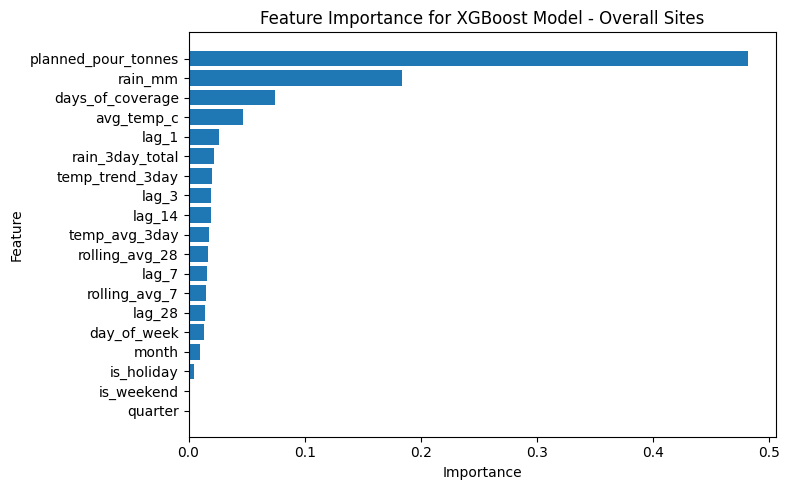

In [57]:
# plot feature importance for XGBoost model for overall sites
plt.figure(figsize=(8, 5))

plt.barh(
  overall_feature_importance_df['feature'],
  overall_feature_importance_df['importance']
)

plt.gca().invert_yaxis()
plt.title("Feature Importance for XGBoost Model - Overall Sites")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [58]:
# save xgboost model in pickle format
import pickle
import pathlib as Path


xgb_model_save_path = Path.Path("../reports/xgboost_model_finetuned.pkl")

with open(xgb_model_save_path, 'wb') as f:
    pickle.dump(xgb_model, f)

print(f"XGBoost model saved to {xgb_model_save_path}")

XGBoost model saved to ../reports/xgboost_model_finetuned.pkl


In [59]:
# save xgboost metrics to CSV
xgb_metrics_save_path = Path.Path("../reports/xgboost_metrics.csv")
xgb_sites_metrics_df.to_csv(xgb_metrics_save_path, index=False)
print(f"XGBoost metrics saved to {xgb_metrics_save_path}")

XGBoost metrics saved to ../reports/xgboost_metrics.csv


In [60]:
# load sarimax metrics and xgboost metrics for comparison
sarimax_metrics_path = Path.Path("../reports/sarimax_metrics.csv")
xgb_metrics_path = Path.Path("../reports/xgboost_metrics.csv")

sarimax_metrics_df = pd.read_csv(sarimax_metrics_path)
xgb_metrics_df = pd.read_csv(xgb_metrics_path)
sarimax_metrics_df = sarimax_metrics_df.rename(columns={
  'MAPE': "SARIMAX MAPE",
  'RMSE': "SARIMAX RMSE"
})

xgb_metrics_df = xgb_metrics_df.rename(columns={
  'MAPE': "XGBoost MAPE",
  'RMSE': "XGBoost RMSE"
})

model_comparison_df = sarimax_metrics_df.merge(
  xgb_metrics_df,
  on='site_id',
  how='inner'
)

model_comparison_df['Better_MAPE_Model'] = np.where(
  model_comparison_df['SARIMAX MAPE'] <= model_comparison_df['XGBoost MAPE'], 
  'SARIMAX',
  'XGBoost'
)

model_comparison_df['Better_RMSE_Model'] = np.where(
  model_comparison_df['SARIMAX RMSE'] <= model_comparison_df['XGBoost RMSE'], 
  'SARIMAX',
  'XGBoost'
)

model_comparison_df['Overall_Better_Model'] = np.where(
  (model_comparison_df['Better_MAPE_Model'] == 'SARIMAX') &
  (model_comparison_df['Better_RMSE_Model'] == 'SARIMAX'),
  'SARIMAX',
  np.where(
    (model_comparison_df['Better_MAPE_Model'] == 'XGBoost') &
    (model_comparison_df['Better_RMSE_Model'] == 'XGBoost'),
    'XGBoost',
    'Mixed'
  )
)

model_comparison_df

,site_id,SARIMAX MAPE,SARIMAX RMSE,XGBoost MAPE,XGBoost RMSE,Better_MAPE_Model,Better_RMSE_Model,Overall_Better_Model
0,SITE_001,53.88,13.21,39.52,10.59,XGBoost,XGBoost,XGBoost
1,SITE_002,3.78,0.50,1.23,0.18,XGBoost,XGBoost,XGBoost
2,SITE_003,27.52,10.44,16.35,6.85,XGBoost,XGBoost,XGBoost
3,SITE_004,3.35,0.44,4.63,0.93,SARIMAX,SARIMAX,SARIMAX
4,SITE_005,30.60,11.85,20.10,8.73,XGBoost,XGBoost,XGBoost
5,SITE_006,25.61,10.04,10.86,5.95,XGBoost,XGBoost,XGBoost
6,SITE_007,37.55,10.95,21.39,7.41,XGBoost,XGBoost,XGBoost
7,SITE_008,35.72,11.57,26.85,8.04,XGBoost,XGBoost,XGBoost
8,SITE_009,3.37,0.48,1.25,0.16,XGBoost,XGBoost,XGBoost
9,SITE_010,45.32,13.46,34.60,9.40,XGBoost,XGBoost,XGBoost


In [61]:
report_path = Path.Path("../reports/xgboost_feature_engineering_report.md")

top_features_text = overall_feature_importance_df.head(10).to_markdown(index=False)
comparison_text = model_comparison_df.to_markdown(index=False)

report = f"""# XGBoost Feature Engineering Results

## Overview

This report documents the feature-engineered XGBoost model and compares its performance against the baseline SARIMAX model.

## Engineered Features

The following feature groups were added:

- Date features: `day_of_week`, `month`, `quarter`, `is_weekend`, `is_holiday`
- Consumption lags: `lag_1`, `lag_3`, `lag_7`, `lag_14`, `lag_28`
- Rolling averages: `rolling_avg_7`, `rolling_avg_28`
- Inventory metric: `days_of_coverage`
- Weather features: `rain_total_3d`, `temp_avg_3d`, `temp_trend_3d`

## Feature Importance

![XGBoost Feature Importance](xgboost_feature_importance.png)

### Top Features

{top_features_text}

## Performance Comparison Matrix

{comparison_text}

## Artifacts

- Feature importance plot: `xgboost_feature_importance.png`
- Performance comparison matrix: `model_performance_comparison.csv`
- Markdown report: `xgboost_feature_engineering_report.md`
"""

report_path.write_text(report, encoding="utf-8")

print(f"Saved markdown report to: {report_path}")

Saved markdown report to: ../reports/xgboost_feature_engineering_report.md
